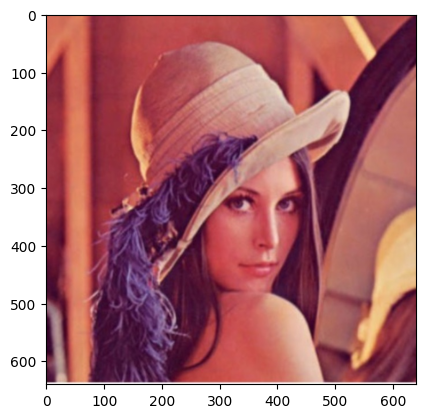

conv_img.shape---> torch.Size([1, 4, 320, 320])


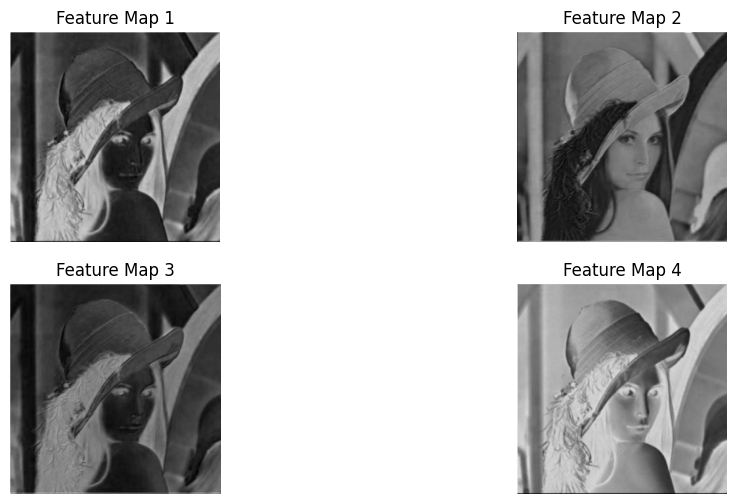

In [16]:
"""
案例:
    演示卷积层的API, 用于 提取图像的局部特征, 获取: 特征图(Feature Map)

卷积神经网络介绍:
    概述:
        全称叫: Convolutional neural network, 即: 包含卷积层的神经网络.
    组成:
        卷积层(Convolutional):
            用于提取图像的 局部特征, 结合 卷积核(每个卷积核 = 1个神经元) 实现, 处理后的结果叫: 特征图.
        池化层(Pooling):
            用于 降维, 降采样
        全连接层(Full Connected, fc, linear):
            用于 预测结果, 并输出结果的.
    特征图计算方式:
        N = (W - F + 2*P) / S   +  1
        W: 输入图像的大小
        F: 卷积核的大小
        P: 填充的大小
        S: 步长
        N: 输出图像的大小(特征图大小)
"""

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def dm():
    img = plt.imread("./data/female.jpg")
    plt.imshow(img)
    plt.show()
    # 打印图像信息 img为ndarray
    """
    - np.ndarray的[h, w, c]格式：数组中第一层元素为图像的每一行像素，第二层元素为每一列像素，最后一层元素为每一个通道的像素值，它将图片中的每一个像素作为描述单元，记录它三个通道的像素值。
    - Tensor的[c, h, w]格式：数组中第一层元素为图像的三个通道，第二层元素为某个通道上的一行像素，第三层为该通道上某列的像素值，它将图像某个通道的某行像素值作为描述单元。
    """
    # print(f"img:{img},imgType:{type(img)},shape:{img.shape}")  # Height（高度）, Width（宽度）, Channels（通道）‌：HWC(640,640,3)

    # 把图像的形状从HWC转换为CHW
    img2 = torch.tensor(img,dtype=torch.float)
    img2 = img2.permute(2, 0, 1)
    # print(f"img2:{img2},img2Type:{type(img2)},shape:{img2.shape}")  # CHW(3,640,640)，3通道640*640

    # 因为这里只有一张图像数。变为4维张量，表示有1张图像
    img3 = img2.unsqueeze(0) # 添加一个0维度, 变为4维张量（1,3,640,640）
    # print("img3.shape--->", img3.shape)

    # 创建卷积对象
    # 参1：输入图像的通道数
    # 参2：输出图像的通道数：卷积核的数量，4个卷积核和图像进行卷积运算，提取4个特征图
    # 参3：卷积核的大小
    conv = nn.Conv2d(in_channels=3,out_channels=4,kernel_size=3,stride=2,padding=1)

    # 卷积计算
    conv_img = conv(img3)
    print("conv_img.shape--->", conv_img.shape)  # (1,4,320,320) 4个特征图，每个特征图的大小为320*320

    # 可视化特征图
    plt.figure(figsize=(12, 6))
    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(conv_img[0, i].detach().numpy(), cmap='gray')
        plt.title(f"Feature Map {i+1}")
        plt.axis('off')
    plt.show()
if __name__ == "__main__":
    dm()